# Long-time limit


In "Quantum enhanced Markov chains require fine-tuned quenches" by Alev Orfi and Dries Sels, we learned that finding optimal hyperparemeters for the quantum proposal is no simple task. This is even more difficult in the context of constraints. In the work, they suggest using the "long time" limit, such that we only need to optimise the mixing parameter. In their work they redefine the mixing strength with a parameter $h$, such that:

$$H = H_c+ h\sum^N_{i=1}\sigma_i^x$$

We can use this notation, by setting gamma = h and

coupling_weights[problem_hamiltonian_indices] = (1-gamma)



In [2]:
import numpy as np
from matplotlib import pyplot as plt
from qemcmc.spectralgap import SpectralGap
from tqdm.notebook import tqdm
from qemcmc.sampler import ClassicalProposal, QeProposal
import numpy as np
from qemcmc.model import ModelMaker

# imports
import itertools
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import joblib

# imports from qemcmc
from qemcmc.model import EnergyModel, ConstraintModel,ModelMaker
from qemcmc.sampler import QeProposal, ClassicalProposal
from qemcmc.coarse_grain import CoarseGraining

from joblib import Parallel, delayed
import numpy as np
from tqdm import tqdm
from CSThelpers import *

In [3]:




def constraint_checker_func(bitstring: str) -> bool:
    """In {0, 1} representation, this constraint means no two adjacent bits can both be 1"""
    return is_causal_matrix(bitstring_to_matrix(bitstring))






In [4]:
def process_single_model_slow(model, t, h,states_to_test):
    """
    Computes metrics for a single model instance at parameters t and h.
    """
    coupling_weights = [1.0/(1-h) for _ in range(len(model.constraint_couplings))]
    if t<1:
        r = int(3)
    else:
        r = int(t//0.8)
    quantum_proposal = QeProposal(model, gamma=h, time=t, coupling_weights=coupling_weights, coarse_graining = cg, m= num_subgroups, r = r)#, delta_t=0.1)

    """basis_states = [0, 2**model.n - 1] + [i for i in np.linspace(1,2**model.n-2, 10, dtype = int)] 
    print([model.constraint_func(bin(state)[2:].zfill(model.n_spins)) for state in basis_states])
    quantum_proposal.CM.check_Hamiltonian(basis_states, model.couplings)
    for state in basis_states:
        print(type(state))"""

    hamming_weight_of_jump = 0# Example: weights decrease with Hamming distance

    self_proposals = 0
    invalid_proposals = 0
    valid_proposals = 0
    hamming_weight_of_jump = 0
    for state in states_to_test:
        for i in range(10):
            new_state = quantum_proposal.update(state)
            if new_state == state:
                self_proposals += 1
            elif not model.constraint_func(new_state):
                invalid_proposals += 1
            else:
                valid_proposals +=1

                hamming_weight_of_jump +=  np.sum(np.bitwise_xor(np.array(list(state), dtype=int), np.array(list(new_state), dtype=int)))
        
    #print("self_proposals: ", self_proposals)
    #print("invalid_proposals: ", invalid_proposals)
    #print("valid_proposals: ", valid_proposals)
    total_proposals = self_proposals + invalid_proposals + valid_proposals
    self_rejections_percent = 100 * self_proposals / total_proposals
    invalid_proposals_percent = 100 * invalid_proposals / total_proposals
    valid_proposals_percent = 100 * valid_proposals / total_proposals
    if valid_proposals == 0:
        print("No valid proposals were made, cannot compute hamming weight of jump")
        return [self_rejections_percent, invalid_proposals_percent, 0], np.nan
    #return self_rejections_percent, invalid_proposals_percent, valid_proposals_percent
    return [    self_rejections_percent,
                invalid_proposals_percent,
                valid_proposals_percent
            ], hamming_weight_of_jump / valid_proposals


In [5]:
def generate_kr_ish_matrix(n):
    n2 = n // 2
    n1 = (n - n2) // 2
    n3 = n - n1 - n2
    
    adj = np.zeros((n, n), dtype=int)
    
    l1 = np.arange(0, n1)
    l2 = np.arange(n1, n1 + n2)
    l3 = np.arange(n1 + n2, n)

    # 1. Deterministic 50% density for L1->L2 and L2->L3 using parity
    for i in l1:
        for j in l2:
            u = np.random.rand()
            if u>0.5:
                adj[i, j] = 1
                
    for j in l2:
        for k in l3:
            u = np.random.rand()
            if u>0.5 and (j + k) % 2 == 0:
                adj[j, k] = 1


    adj = transitive_closure(adj)
    # # 2. Enforce Transitivity for L1->L3
    # # A_ik = 1 if there exists j such that A_ij=1 AND A_jk=1
    # forced_l1_l3 = (adj[l1, :][:, l2] @ adj[l2, :][:, l3]) > 0
    
    # # 3. Fill L1->L3 block
    # for i_idx, i in enumerate(l1):
    #     for k_idx, k in enumerate(l3):
    #         if forced_l1_l3[i_idx, k_idx]:
    #             adj[i, k] = 1
    #         else:
    #             # Apply parity to non-forced relations to maintain density
    #             if (i + k) % 2 == 0:
    #                 adj[i, k] = 1
                    
    #return adj

    #return the upper triangle as a bitstring
    return matrix_to_bitstring(adj)

print(generate_kr_ish_matrix(20))

0000001101011011111000011011100111101001011111011111110111011101010101000010111111111000000000101000000000000000000000010100000000010100000000001000000000000100010001010010101010000000000000


[[0 0 1 1 0 1 0 1 1 1]
 [0 0 1 1 1 1 0 1 1 1]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1 0 1]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]
{0: (0, 0), 1: (1, 0), 2: (-2, 1), 3: (-1, 1), 4: (0, 1), 5: (1, 1), 6: (2, 1), 7: (1, 2), 8: (2, 2), 9: (3, 2)}


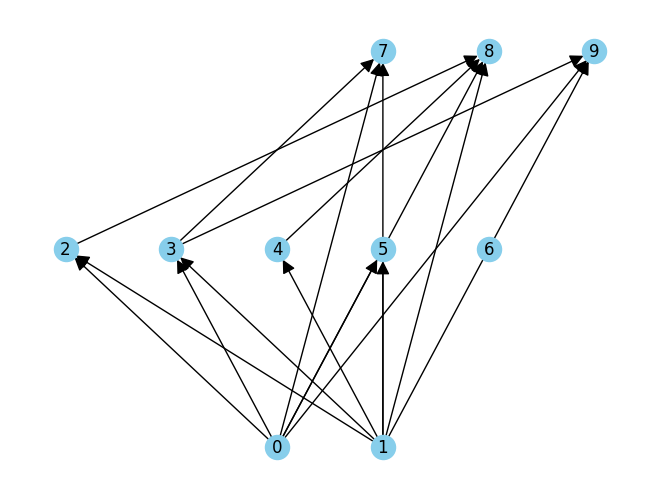

In [18]:
import networkx as nx
import matplotlib.pyplot as plt
C = 10
adj = bitstring_to_matrix(generate_kr_ish_matrix(C))
print(adj)
# Generate your matrix 'adj' using your function
# adj = generate_deterministic_kr_matrix(20)
n2 = C // 2
n1 = (C - n2) // 2
n3 = C - n1 - n2
# Create Graph
G = nx.from_numpy_array(adj, create_using=nx.DiGraph)

# Compute Transitive Reduction (The Hasse Diagram)
TR = G#nx.transitive_reduction(G)

# Plotting with layered layout
pos = {i: (i, 0) for i in range(n1)} # L1
pos.update({i + n1: (i - 2, 1) for i in range(n2)}) # L2
pos.update({i + n1 + n2: (i + 1, 2) for i in range(n3)}) # L3
print(pos)
nx.draw(TR, pos, with_labels=True, node_color='skyblue', arrowsize=20)
plt.show()

In [ ]:




def run_search_over_hyperparameters(h_list, t_list, C, num_subgroups):

    cg = CoarseGraining(C, repeated = False)



    print(f"using {n} bits to represent the causal set of cardinality {C}")
    print("The length of each subgroup is ", n//num_subgroups, "meaning that the quantum proposal will be updating ", n//num_subgroups, " qubits at a time")

    TC_couplings = get_TC_couplings(C)
    TC_couplings_list = [TC_couplings[0], TC_couplings[1]]
    print("TC_couplings_list shapes: ", [coupling.shape for coupling in TC_couplings_list])
    TC_model = ConstraintModel(n, constraint_couplings = [coupling for coupling in TC_couplings_list], name="TC Constraint Model", constraint_func=constraint_checker_func, constraint_signs = [1 for coupling in TC_couplings_list], couplings = None, model_type ="binary", cost_function_signs=None)

    initial_states = []
    initial_states.append("0" * n)
    initial_states.append("1" * n)


    for i in range(2):
        initial_states.append(generate_kr_ish_matrix(C))


    for init_s in initial_states:
        print("initial state: ", init_s)
        print("constraint value of initial state: ", constraint_checker_func(init_s))


    model = TC_model






    qres = []
    # n_jobs=-1 uses all available CPU cores
    parallel_pool = Parallel(n_jobs=-1)
    hamming_distance_results = np.zeros((len(h_list), len(t_list)))
    pbar_h = tqdm(h_list, desc="Looping through h")
    for k, h in enumerate(pbar_h):
        pbar_h.set_description(f"h: {h:.2f}")
        
        
        # Generate models for the current batch

        # for l, t in tqdm(enumerate(t_list), desc="t loop"):
        #     # Dispatching models in parallel via joblib
        #     results = process_single_model_slow(model, t, h)
        q_res_is = []
        for init_state in initial_states:
            results_list = parallel_pool(delayed(process_single_model_slow)(model, t, h, [init_state,]) for t in t_list)

            q_res_n = []
            for l, t in enumerate(t_list):
                
                results= results_list[l]
                avgs = results[0]
                avg_hamming_distance = np.nanmean([results[1]])
                hamming_distance_results[k, l] = avg_hamming_distance

            
                q_res_n.append([
                    [avgs[0]], 
                    [avgs[1]], 
                    [avgs[2]]
                ])
            q_res_is.append(q_res_n)

        qres.append(q_res_is)

    qres = np.array(qres)

    print("the dimensiuons of qres are: ", qres.shape)
    print("They go as h, initial states,t , and the last two dimensions are the metrics and their error bars (which are empty in this case since we only have one run per t value)")
    return qres, initial_states

In [ ]:
C = 20
n = C*(C-1)//2
num_subgroups = 19
t_list = np.logspace(-0.9,1,6)
print("t_list: ", t_list)


h_list = [0.1,0.3,0.7,1.1]#[0.01, 0.05, 0.1,0.2,0.3,0.5,0.7,0.9,1.3,1.9,3,5,10]#np.logspace(-1, 1, 10)
print("h_list: ", h_list)

q_res, initial_states = run_search_over_hyperparameters(h_list, t_list, C, num_subgroups)

t_list:  [ 0.12589254  0.30199517  0.72443596  1.73780083  4.16869383 10.        ]
h_list:  [0.1, 0.3, 0.7, 1.1]
using 190 bits to represent the causal set of cardinality 20
The length of each subgroup is  10 meaning that the quantum proposal will be updating  10  qubits at a time
TC_couplings_list shapes:  [(190, 190), (190, 190, 190)]
Input of a zero-coupling may be intended to sample Uniform distributions, however if this is not your intention, please check your couplings.


C:\Users\Stuart Ferguson\OneDrive - University of Edinburgh\Documents\PhD\CODE\QeMCMC\QeMCMC\src\qemcmc\model\constraint_model.py:101: UserWarning: Could not find enough valid initial states satisfying the constraint. Found 0 valid states after 1000 attempts. You may want to provide them manually if more are needed.
  warnings.warn(


initial state:  0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
constraint value of initial state:  True
initial state:  1111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111
constraint value of initial state:  True
initial state:  0000110100010111110000000100000000000000111101011111110010000100011000100110101010100000000000101000000000001000000000000001000000000000000000100000000000000100000000000010100000100000000000
constraint value of initial state:  True
initial state:  0000111001110011111000110110110111011000100100010101010011001010001110011100101001101000000000100010000000000000000000000100000000010000000010001000000010000000010001010000101000100000000000
constraint value of initial state:  True


h: 1.10: 100%|██████████| 4/4 [01:31<00:00, 22.83s/it]  

the dimensiuons of qres are:  (4, 4, 6, 3, 1)
They go as h, initial states,t , and the last two dimensions are the metrics and their error bars (which are empty in this case since we only have one run per t value)


[0.1, 0.3, 0.7, 1.1]


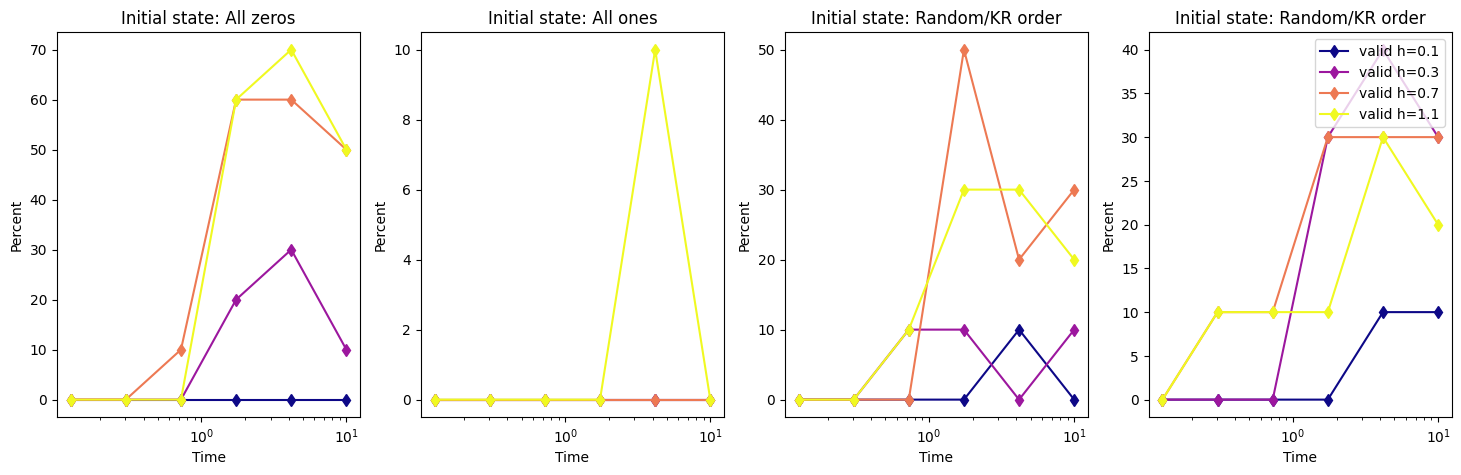

In [ ]:
qres = q_res_ns 
initial_states = []
initial_states.append("0" * n)
initial_states.append("1" * n)


for i in range(2):
    initial_states.append(generate_kr_ish_matrix(C))


    
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
print(h_list)
color_range = np.linspace(0, 1, qres.shape[0])
color_range_2 = np.linspace(0, 1, qres.shape[1])
fig, axs = plt.subplots(1, len(initial_states), figsize=(18, 5))
for i in range(qres.shape[0]):
    #if h_list[i] != h_list[2]:#1.1: # Example: only plot for a specific h value
    #   continue

    c_1 = "b"#plt.cm.viridis(color_range[i])
    c_2 = "lightblue"#plt.cm.plasma(color_range[i])
    c_3 = plt.cm.plasma(color_range[i])

    for j in range(qres.shape[1]):
        #plt.errorbar(t_list, qres[i,:,0,0], yerr=qres[i,:,0,1], marker='o', label = f"invalid h={np.round(h_list[i],2)}", color = c_1, alpha = 1)
        #plt.errorbar(t_list, qres[i,:,1,0], yerr=qres[i,:,1,1], marker='o', label = f"self h={np.round(h_list[i],2)}", color = c_2, alpha = 1)

        #plt.plot(t_list, qres[i,:,0,0], marker='o', label = f"self h={np.round(h_list[i],2)}", linestyle='-.', color = c_3, alpha = 1)
        #plt.plot(t_list, qres[i,:,1,0], marker='x', label = f"invalid h={np.round(h_list[i],2)}", linestyle='--', color = c_3, alpha = 1)
        axs[j].plot(t_list, qres[i,j,:,2,0], marker='d', color = c_3, alpha = 1, label = f"valid h={np.round(h_list[i],2)}")


for j in range(qres.shape[1]):
    if initial_states[j] == "0" * n:
        initial_state_label = "All zeros"
    elif initial_states[j] == "1" * n:
        initial_state_label = "All ones"
    else:
        initial_state_label = "Random/KR order"
    axs[j].set_title(f"Initial state: {initial_state_label}")
    axs[j].set_ylabel("Percent")
    axs[j].set_xlabel("Time")
    axs[j].set_xscale("log")
    

plt.legend(loc="upper right")

plt.show()

[0.1, 0.3, 0.7, 1.1]


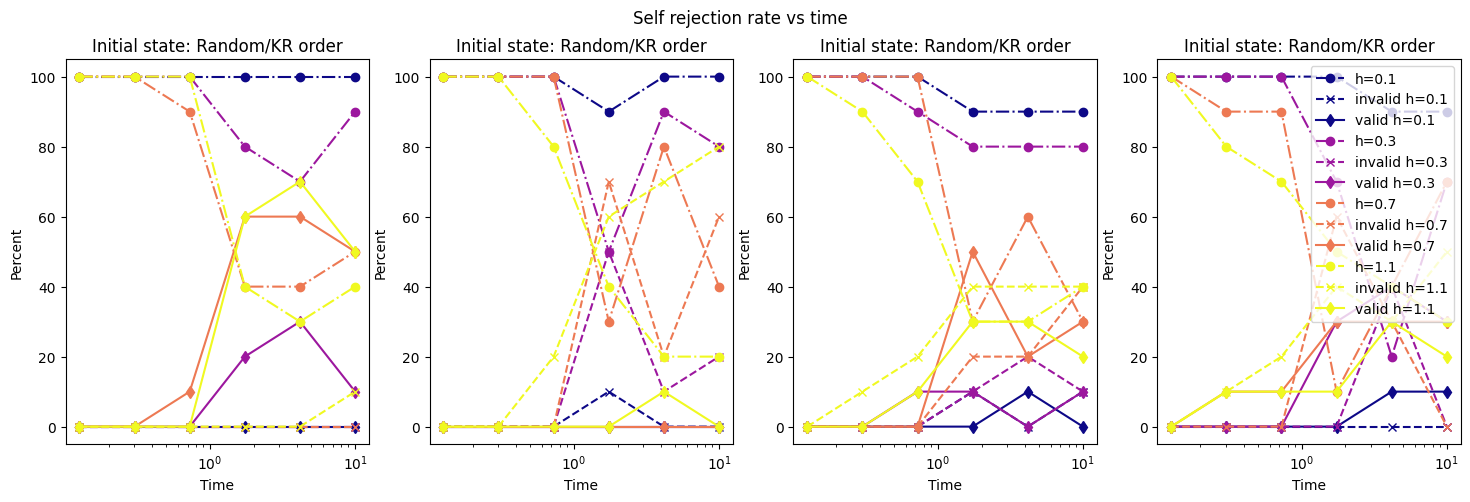

In [34]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
print(h_list)

fig, axs = plt.subplots(1, len(initial_states), figsize=(18, 5))
color_range = np.linspace(0, 1, qres.shape[0])
color_range_2 = np.linspace(0, 1, qres.shape[1])
for i in range(qres.shape[0]):
    #if h_list[i] != 1.3:
    #   continue

    c_1 = "b"#plt.cm.viridis(color_range[i])
    c_2 = "lightblue"#plt.cm.plasma(color_range[i])
    c_3 = plt.cm.plasma(color_range[i])

    #plt.errorbar(t_list, qres[i,:,0,0], yerr=qres[i,:,0,1], marker='o', label = f"invalid h={np.round(h_list[i],2)}", color = c_1, alpha = 1)
    #plt.errorbar(t_list, qres[i,:,1,0], yerr=qres[i,:,1,1], marker='o', label = f"self h={np.round(h_list[i],2)}", color = c_2, alpha = 1)
    for j in range(qres.shape[1]):
        axs[j].plot(t_list, qres[i,j,:,0,0], marker='o', label = f"h={np.round(h_list[i],2)}", linestyle='-.', color = c_3, alpha = 1)
        axs[j].plot(t_list, qres[i,j,:,1,0], marker='x', label = f"invalid h={np.round(h_list[i],2)}", linestyle='--', color = c_3, alpha = 1)
        axs[j].plot(t_list, qres[i,j,:,2,0], marker='d', color = c_3, alpha = 1, label = f"valid h={np.round(h_list[i],2)}")
        axs[j].set_title(f"Initial state: {initial_state_label}")
        axs[j].set_ylabel("Percent")
        axs[j].set_xlabel("Time")
        axs[j].set_xscale("log")
    
    

plt.ylabel("Percent")
plt.xlabel("Time")
fig.suptitle("Self rejection rate vs time")
plt.legend(loc="upper right")
plt.show()

NameError: name 'hamming_distance_results' is not defined

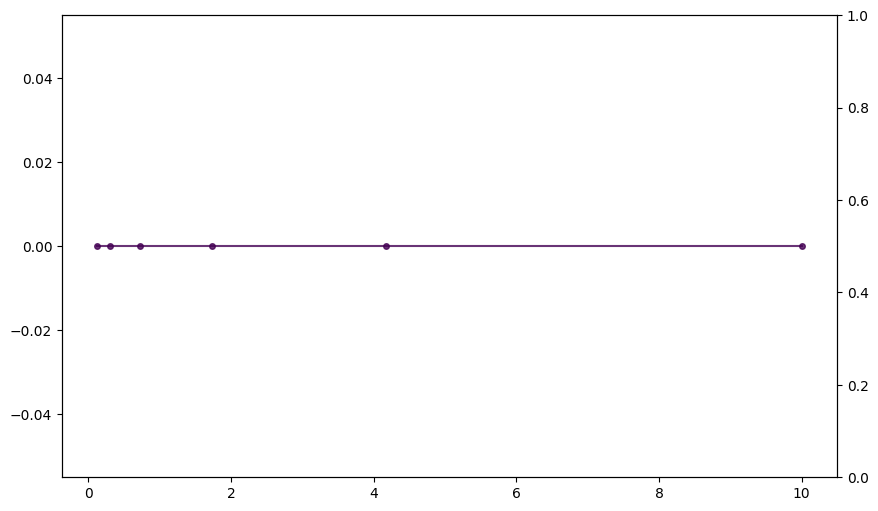

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Setup colors
color_range = np.linspace(0, 1, qres.shape[0])

fig, ax1 = plt.subplots(figsize=(10, 6))
# Create the secondary axis
ax2 = ax1.twinx() 

for i in range(qres.shape[0]):
    # Using a single colormap to represent different h values
    c = plt.cm.viridis(color_range[i])
    h_val = np.round(h_list[i], 2)

    # Plot Percentages on AX1
    ax1.plot(t_list, qres[i,0,:,2,0], 
                 marker='o', markersize=4, linestyle='-',
                 label=f"Valid % (h={h_val})", color=c, alpha=0.8)

    # Plot Hamming Distance on AX2
    ax2.plot(t_list, hamming_distance_results[i,:], 
             linestyle="--", label=f"Hamming (h={h_val})", color=c)

# Set Labels and Scales
ax1.set_xlabel("Time ($t$)")
ax1.set_ylabel("Percent (%)", color='teal')
ax1.tick_params(axis='y', labelcolor='teal')

ax2.set_ylabel("Avg Hamming Distance", color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

plt.title("Quantum Proposal Metrics: Rejection vs Hamming Distance")

# Combined Legend Logic (Optional but recommended)
# This pulls labels from both axes into one box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize='small', ncol=2)

plt.tight_layout()
plt.show()

In [1]:
def generate_constraint_model(C):
    n__ = C*(C-1)//2
    TC_couplings = get_TC_couplings(C)
    TC_couplings_list = [TC_couplings[0], TC_couplings[1]]
    TC_model = ConstraintModel(n__, constraint_couplings = [coupling for coupling in TC_couplings_list], name="TC Constraint Model", constraint_func=constraint_checker_func, constraint_signs = [1 for coupling in TC_couplings_list], couplings = None, model_type ="binary", cost_function_signs=None)
    return TC_model

In [12]:


# Define parameters of experiment
temp = 1/5

t_list = np.logspace(-1,0.5,10)#np.logspace(-1,1,20)

print("t_list: ", t_list)
# Number of models to test at each n
number_of_models = 1



h = 0.7

n_list = [5, 16, 20, 21, 25]#np.logspace(-1, -.7, 5)

qres_n_spins = []
# n_jobs=-1 uses all available CPU cores
parallel_pool = Parallel(n_jobs=-1)
hamming_distance_results = np.zeros((len(n_list), len(t_list)))
pbar_n = tqdm(n_list, desc="Looping through n")
for k, n in enumerate(pbar_n):
    pbar_n.set_description(f"n: {n}")
    q_res_n = []
    

    num_max_qubits = 10
    num_bits = n*(n-1)//2
    num_subgroups = np.ceil(num_bits/num_max_qubits)

    print("Num subgroups: ", num_subgroups)
    print(f"using {num_bits} bits to represent the causal set of cardinality {n}")
    print(f"the number of bits is {num_bits} and the number of subgroups is {num_subgroups}, meaning that the quantum proposal will be updating {num_bits//num_subgroups} qubits at a time")

    model = generate_constraint_model(n)
    
    models = [model for _ in range(number_of_models)]
    
    initial_states = []
    initial_states.append("0" * num_bits)
    initial_states.append("1" * num_bits)
    for i in range(2):
        initial_states.append(generate_kr_ish_matrix(n))

    cg = CoarseGraining(num_bits, repeated = False)


    for l, t in enumerate(tqdm(t_list, desc="t loop", leave=False)):
        # Dispatching models in parallel via joblib
        results = parallel_pool(
           delayed(process_single_model_slow)(m, t, h, initial_states) for m in models
        )
        # print(initial_states[-1])
        # process_single_model_slow(model,t,h, initial_states )
        avgs_batch = np.array([res[0] for res in results])
        avg_hamming_distance = np.mean([res[1] for res in results])
        hamming_distance_results[k, l] = avg_hamming_distance

        # Calculate mean and standard error across the parallelized models
        means = np.mean(avgs_batch, axis=0)
        sterrs = np.std(avgs_batch, axis=0) / np.sqrt(len(models))
            
        q_res_n.append([
            [means[0], sterrs[0]], 
            [means[1], sterrs[1]], 
            [means[2], sterrs[2]]
        ])

    qres_n_spins.append(q_res_n)
    pbar_n.set_postfix({"Avg Hamming": avg_hamming_distance})

qres_n_spins = np.array(qres_n_spins)
# dimensions of qres_n_spins are n, t, and the last two dimensions are the metrics and their error bars
#[    self_rejections_percent,
#     invalid_proposals_percent,
#     valid_proposals_percent
#     ], hamming_weight_of_jump / valid_proposals

t_list:  [0.1        0.14677993 0.21544347 0.31622777 0.46415888 0.68129207
 1.         1.46779927 2.15443469 3.16227766]


n: 5:   0%|          | 0/5 [00:00<?, ?it/s]             

Num subgroups:  1.0
using 10 bits to represent the causal set of cardinality 5
the number of bits is 10 and the number of subgroups is 1.0, meaning that the quantum proposal will be updating 10.0 qubits at a time
Input of a zero-coupling may be intended to sample Uniform distributions, however if this is not your intention, please check your couplings.


n: 16:  20%|██        | 1/5 [00:52<03:28, 52.01s/it, Avg Hamming=4.55]

Num subgroups:  12.0
using 120 bits to represent the causal set of cardinality 16
the number of bits is 120 and the number of subgroups is 12.0, meaning that the quantum proposal will be updating 10.0 qubits at a time
Input of a zero-coupling may be intended to sample Uniform distributions, however if this is not your intention, please check your couplings.


...

n: 21:  60%|██████    | 3/5 [02:50<02:00, 60.26s/it, Avg Hamming=2.71]

Num subgroups:  21.0
using 210 bits to represent the causal set of cardinality 21
the number of bits is 210 and the number of subgroups is 21.0, meaning that the quantum proposal will be updating 10.0 qubits at a time
Input of a zero-coupling may be intended to sample Uniform distributions, however if this is not your intention, please check your couplings.


n: 25:  80%|████████  | 4/5 [04:30<01:16, 76.01s/it, Avg Hamming=3.86]

Num subgroups:  30.0
using 300 bits to represent the causal set of cardinality 25
the number of bits is 300 and the number of subgroups is 30.0, meaning that the quantum proposal will be updating 10.0 qubits at a time
Input of a zero-coupling may be intended to sample Uniform distributions, however if this is not your intention, please check your couplings.


n: 25: 100%|██████████| 5/5 [07:47<00:00, 93.44s/it, Avg Hamming=3.17] 


In [2]:
import numpy as np
factors_of_num_bits = []
for n in range(4,50):
    num_bits = n*(n-1)//2
    #print(f"n: {n}, num_bits: {num_bits}")
    #print("Factors of num_bits: ", [i for i in range(1, num_bits+1) if num_bits % i == 0])
    factors = [i for i in range(1, num_bits+1) if num_bits % i == 0]
    factors_of_num_bits.append(factors)
    if 10 in factors:
        print(f"n: {n}, num_bits: {num_bits}, factors: {factors}")

l = []
for f in factors_of_num_bits:
    l = l + f
factors, popularity = np.unique(l, return_counts=True)

for i, factor in enumerate(factors):
    if factor >4:
        if popularity[i] >3:
            print(f"Factor: {factor}, Popularity: {popularity[i]}")

n: 5, num_bits: 10, factors: [1, 2, 5, 10]
n: 16, num_bits: 120, factors: [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 24, 30, 40, 60, 120]
n: 20, num_bits: 190, factors: [1, 2, 5, 10, 19, 38, 95, 190]
n: 21, num_bits: 210, factors: [1, 2, 3, 5, 6, 7, 10, 14, 15, 21, 30, 35, 42, 70, 105, 210]
n: 25, num_bits: 300, factors: [1, 2, 3, 4, 5, 6, 10, 12, 15, 20, 25, 30, 50, 60, 75, 100, 150, 300]
n: 36, num_bits: 630, factors: [1, 2, 3, 5, 6, 7, 9, 10, 14, 15, 18, 21, 30, 35, 42, 45, 63, 70, 90, 105, 126, 210, 315, 630]
n: 40, num_bits: 780, factors: [1, 2, 3, 4, 5, 6, 10, 12, 13, 15, 20, 26, 30, 39, 52, 60, 65, 78, 130, 156, 195, 260, 390, 780]
n: 41, num_bits: 820, factors: [1, 2, 4, 5, 10, 20, 41, 82, 164, 205, 410, 820]
n: 45, num_bits: 990, factors: [1, 2, 3, 5, 6, 9, 10, 11, 15, 18, 22, 30, 33, 45, 55, 66, 90, 99, 110, 165, 198, 330, 495, 990]
Factor: 5, Popularity: 18
Factor: 6, Popularity: 16
Factor: 7, Popularity: 13
Factor: 8, Popularity: 6
Factor: 9, Popularity: 10
Factor: 10, Popularit

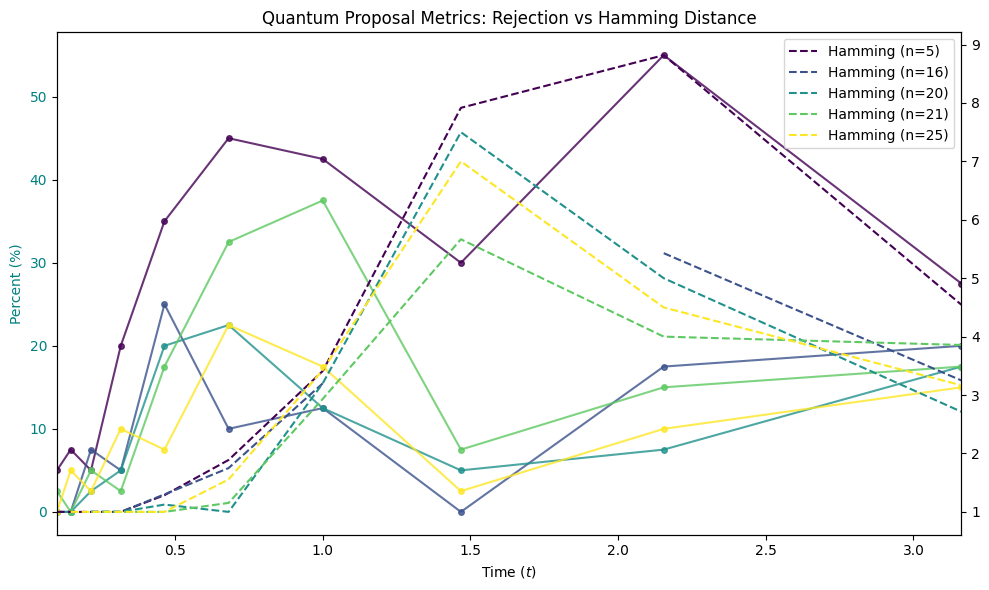

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Setup colors
color_range = np.linspace(0, 1, qres_n_spins.shape[0])

fig, ax1 = plt.subplots(figsize=(10, 6))
# Create the secondary axis
ax2 = ax1.twinx() 

for i in range(qres_n_spins.shape[0]):
    # Using a single colormap to represent different n values
    c = plt.cm.viridis(color_range[i])
    n_val = np.round(n_list[i], 2)
    

    # Plot Percentages on AX1
    ax1.errorbar(t_list, qres_n_spins[i,:,2,0], yerr=qres_n_spins[i,:,2,1], 
                 marker='o', markersize=4, linestyle='-',
                 label=f"Valid % (n={n_val})", color=c, alpha=0.8)
    
    # # fit a line to the valid percentage vs time, and plot it as a dashed line
    # coeffs, cov = np.polyfit(t_list, qres_n_spins[i,:,2,0], deg=2, cov=True)
    # x_fit = np.linspace(t_list[0], t_list[-1], 100)
    # y_fit = np.polyval(coeffs, x_fit)
    # ax1.plot(x_fit, y_fit, linestyle="--", color=c, alpha=0.5)

    # print(f"Fitted coefficients for n={n_val}: ", coeffs)
    # center = -coeffs[1]/(2*coeffs[0]) 
    # print("center of parabola: ", center)
    
    # ax1.vlines(center, ymin=0, ymax=100, color=c, linestyle=":", alpha=0.5, label=f"Peak valid % (n={n_val}) at t={center:.2f})")
    #Plot Hamming Distance on AX2
    ax2.plot(t_list, hamming_distance_results[i,:], 
             linestyle="--", label=f"Hamming (n={n_val})", color=c)

# Set Labels and Scales
ax1.set_xlabel("Time ($t$)")
ax1.set_ylabel("Percent (%)", color='teal')
ax1.tick_params(axis='y', labelcolor='teal')

# ax2.set_ylabel("Avg Hamming Distance", color='purple')
# ax2.tick_params(axis='y', labelcolor='purple')
ax1.set_xlim(np.min(t_list), np.max(t_list))
plt.title("Quantum Proposal Metrics: Rejection vs Hamming Distance")

# Combined Legend Logic (Optional but recommended)
# This pulls labels from both axes into one box
##lines1, labels1 = ax1.get_legend_handles_labels()
#lines2, labels2 = ax2.get_legend_handles_labels()
#ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize='small', ncol=2)
plt.legend()
plt.tight_layout()
plt.show()

t_list:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


NameError: name 'n_list' is not defined

Fitted coefficients for n=4:  [ -3.76630283  40.16711067 -26.29876314]
center of parabola:  5.332432421780025
Fitted coefficients for n=6:  [ -3.30343764  35.45970759 -16.31663794]
center of parabola:  5.3670920272871205
Fitted coefficients for n=8:  [ -2.91495142  31.79764232 -16.57428984]
center of parabola:  5.454231955146381
Fitted coefficients for n=10:  [-2.00573405 21.91962338 -9.96484124]
center of parabola:  5.464239738339667
Fitted coefficients for n=12:  [-1.8362614  20.3540766  -4.81525261]
center of parabola:  5.542260100374465
[ 9.25 11.25  8.   24.75 23.25 28.   29.75 30.5  16.5   6.  ]


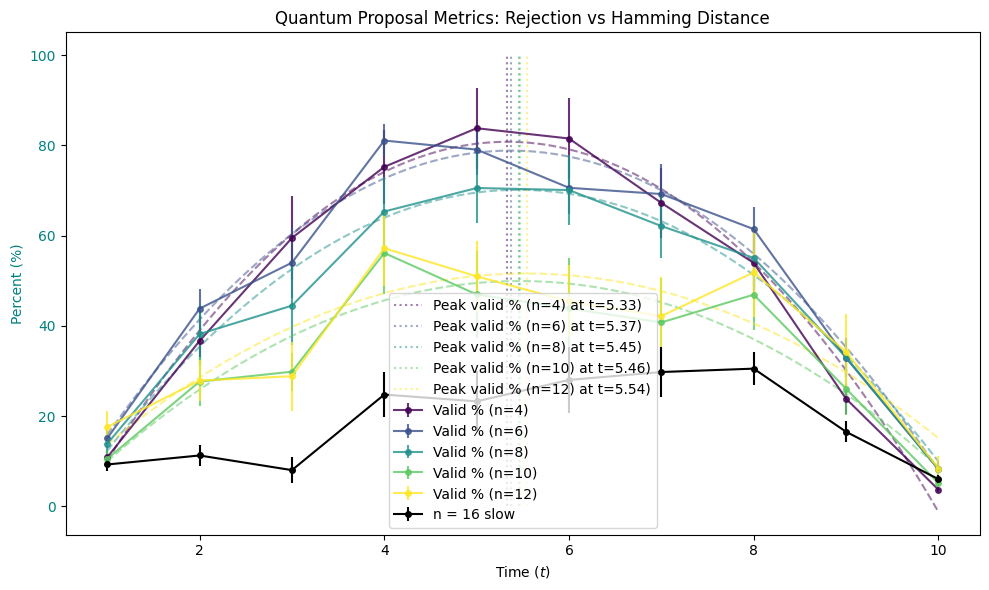

In [123]:
C = 20
n = C*(C-1)//2
cg = CoarseGraining(n, repeated = False)
model = generate_constraint_model(C)
partitions = cg.get_partitions(m=19)
working_state = generate_kr_ish_matrix(C)
for subgroup in partitions:
    local_couplings = model.get_subgroup_couplings(subgroup=subgroup, current_state=working_state, coupling_weights=np.ones(len(model.normalised_couplings)))
    print(local_couplings)

Input of a zero-coupling may be intended to sample Uniform distributions, however if this is not your intention, please check your couplings.


C:\Users\Stuart Ferguson\OneDrive - University of Edinburgh\Documents\PhD\CODE\QeMCMC\QeMCMC\src\qemcmc\model\constraint_model.py:101: UserWarning: Could not find enough valid initial states satisfying the constraint. Found 0 valid states after 1000 attempts. You may want to provide them manually if more are needed.
  warnings.warn(


[array([-21.46805742, -23.77745849, -19.31574061, -27.24156011,
        -3.90136322, -11.38992111,  -4.04145188, -11.53000978,
        14.11958819, -18.30112874]), array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.22474487],
       [ 0.        ,  0.        ,  0.        ,  1.51342001,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  1.51342001,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        , -0.93606974,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.    